#Questão de negócio

Uma empresa está interessada em verificar se a remuneração(salario) dos funcionarios está de acordo com as politicas da empresa.


Para isso uma amostra de 46 colaboradores foi disponibilizada

* Pergunta de negócio: O salario muda de acordo com os anos de educação superior?
* Se muda, é possivel prever o salario a partir de um modelo ?

In [4]:
#manipulação de dados

import pandas as pd
import numpy as np
#gráficos
import matplotlib.pyplot as plt
import seaborn as sns
#estatística
import statsmodels.api as sm

In [5]:
df = pd.read_csv('../data-scripts/6/base_funcionarios_v2.csv', sep=';', index_col='id')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46 entries, 1 to 46
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Salario             46 non-null     float64
 1   Anos_Educ_Superior  46 non-null     int64  
 2   Tempo_Empresa       46 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 1.2 KB


<Axes: xlabel='Anos_Educ_Superior', ylabel='Salario'>

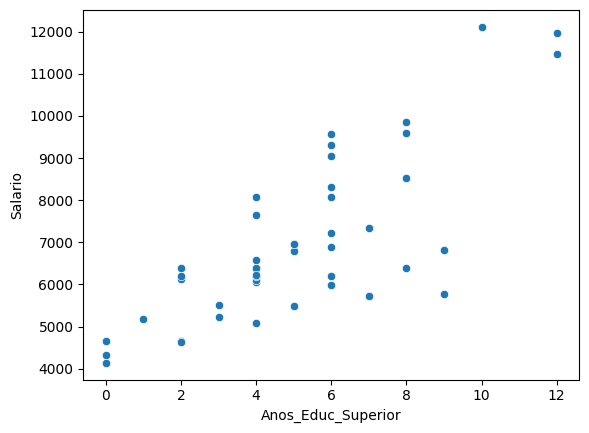

In [7]:
#variável alvo é o eixo "y"
#variável explicativa é o eixo "x"

sns.scatterplot(df, x='Anos_Educ_Superior', y='Salario')

<Axes: xlabel='Tempo_Empresa', ylabel='Salario'>

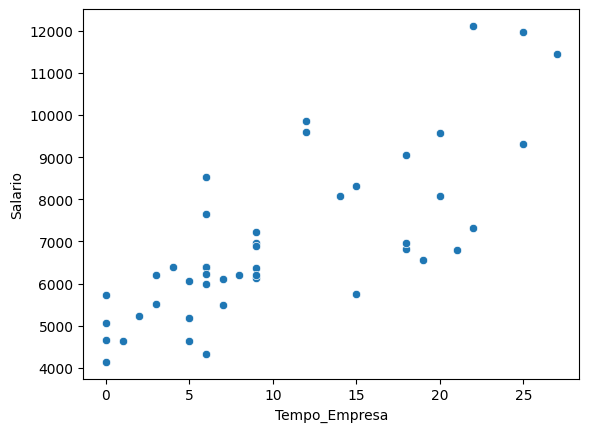

In [8]:
sns.scatterplot(df, x='Tempo_Empresa', y='Salario')

In [9]:
# Correlação de Pearson
df.corr()

,Salario,Anos_Educ_Superior,Tempo_Empresa
Salario,1.000000,0.776992,0.765173
Anos_Educ_Superior,0.776992,1.000000,0.607486
Tempo_Empresa,0.765173,0.607486,1.000000


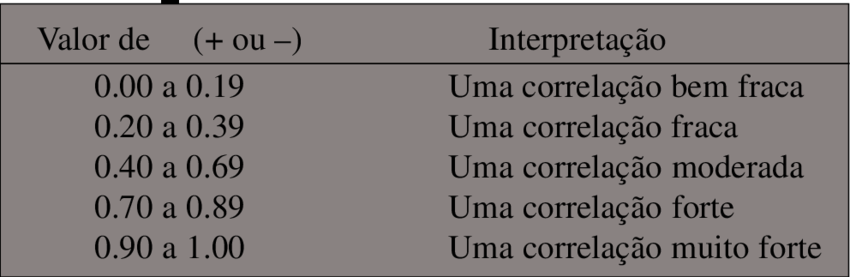

<Axes: >

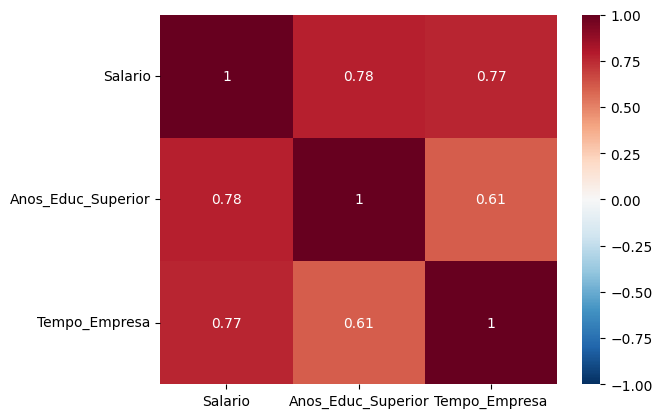

In [10]:
sns.heatmap(df.corr(),
            vmax=1,
            vmin=-1,
            cmap='RdBu_r',
            annot=True)

In [11]:
#variavel alvo
y = df['Salario']

#variavel explicativa
df['intercepto'] = 1
x = df[['intercepto', 'Anos_Educ_Superior', 'Tempo_Empresa']]

In [12]:
#ajuste do modelo
modelo = sm.OLS(y,x)

#treinamento do modelo
resultado = modelo.fit()

In [13]:
print(resultado.summary())
#r-squared e adj. r-squared devem ser parecidos
#std = desvio padrão
#coef intercepto - minimo salario e contar o std
#coef anos educ superior - a cada ano a mais ganha o resultado a mais(ou a menos), e contar tambem o std
#P>|t| - aleatoriedade, deve ser menor que 0.05
#[xxx.xxx   xxx.xxx] não deve passar por 0

                            OLS Regression Results                            
Dep. Variable:                Salario   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     61.17
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           2.66e-13
Time:                        00:11:47   Log-Likelihood:                -381.67
No. Observations:                  46   AIC:                             769.3
Df Residuals:                      43   BIC:                             774.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
intercepto          4056.0591    309

In [14]:
df['Salario_pred'] = 4056.0591 * df['intercepto'] + df['Anos_Educ_Superior'] * 335.3868 + df['Tempo_Empresa'] * 117.6566

In [15]:
df.head(15)

,Salario,Anos_Educ_Superior,Tempo_Empresa,intercepto,Salario_pred
id,,,,,
1,5517.4,3,3,1,5415.1893
2,6399.9,4,6,1,6103.5459
3,6206.7,6,3,1,6421.3497
4,6060.6,4,5,1,5985.8893
5,6122.7,2,9,1,5785.7421
6,6955.0,5,9,1,6791.9025
7,7643.0,4,6,1,6103.5459
8,6210.2,2,8,1,5668.0855
9,5761.0,9,15,1,8839.3893


<Axes: xlabel='Tempo_Empresa', ylabel='Salario'>

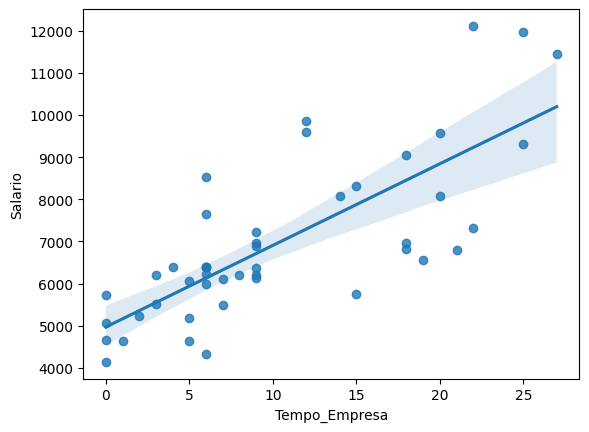

In [16]:
sns.regplot(df, x='Tempo_Empresa', y='Salario')

# Relatório:

- Sim, o salário sobe conforme os anos de ensino superior aumentam, com uma correlação de 77%, e também sobe de acordo com o tempo da empresa, com correlação de 76,5%.
- É possível prever o salário com base nesses dados, a partir de um modelo de regressão linear criado que consegue explicar 74% dos salários sem aleatoriedade.